# Transformaciones de Intensidad en Imágenes
**Curso:** Visión por Computador 
**Estudiante:** Valelry Michel Ochoa Lechuga

**Objetivo:** analizar el efecto de transformaciones puntuales, lineales y no lineales, sobre imágenes en escala de grises y en color (RGB).

Una *transformación puntual* calcula cada píxel de salida usando **solo** el valor del mismo píxel de entrada: $s = T(r)$. No mira a los vecinos, por eso cambia la distribución de intensidades (el histograma) pero no la geometría de la imagen.

**Estructura del notebook**
- Parte 1: Transformaciones lineales en escala de grises (ejercicios 1 a 4)
- Parte 2: Transformaciones no lineales, gamma (ejercicios 5 a 7)
- Parte 3: Transformaciones en imágenes RGB (ejercicios 8 a 15)
- Declaración de uso de herramientas de IA

Las funciones de transformación están en `src/transformaciones.py` y las de graficación en `src/visualizacion.py`, para que el notebook muestre solo lo esencial de cada ejercicio.

In [5]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

proyecto = Path.cwd()
while not (proyecto / "src").is_dir() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
if not (proyecto / "src").is_dir():
    raise FileNotFoundError("No se encontró la carpeta src/. Abra el notebook dentro de la carpeta del proyecto.")
os.chdir(proyecto)
sys.path.insert(0, str(proyecto))

from src.transformaciones import (
    cargar_gris, cargar_rgb, a_uint8, lineal, por_tramos, inversion,
    gamma, curva_gamma, ajuste_lineal_a_gamma,
    lineal_canales, gamma_canales, eliminar_canal, intercambiar_canales, a_gris,
    estadisticas, detalle_en_sombras,
)
from src.visualizacion import comparar, curvas, tabla, histograma

plt.rcParams["figure.dpi"] = 90

## Imágenes de trabajo

Se usan cinco imágenes guardadas en `imagenes/` (todas provienen del conjunto de imágenes de ejemplo de `scikit-image`, de libre uso):

| Archivo | Uso | Descripción |
|---|---|---|
| `gris.png` | Partes 1 y 2 | Fotógrafo (*cameraman*), 512×512, escala de grises con rango completo |
| `bajo_contraste.png` | Ejercicio 2 | Superficie lunar (*moon*), 512×512, casi todos los píxeles entre 78 y 141 |
| `oscura.png` | Ejercicios 4 y 7 | Taza de café **oscurecida artificialmente** con $255\,(I/255)^{3}$: simula una foto subexpuesta; las sombras quedan aplastadas pero las luces (reflejos) se conservan |
| `color.png` | Parte 3 | Taza de café, 400×600, colores cálidos |
| `color2.png` | Parte 3 | Astronauta, 512×512, colores saturados (rojo, azul, blanco) |

Las imágenes se leen con OpenCV. OpenCV carga en orden **BGR**, por eso `cargar_rgb` convierte a **RGB** antes de mostrar con Matplotlib.

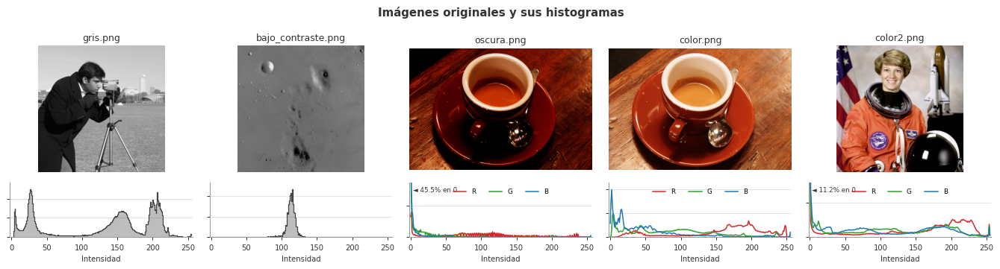

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
gris.png                             I   129.1    73.6    0  255   0.00    0.10      256
bajo_contraste.png                   I   112.2    13.3    0  255   0.09    0.00      178
oscura.png                           R    86.9    63.4    0  255   5.43    0.01      158
oscura.png                           G    26.4    45.1    0  255  23.47    0.20      158
oscura.png                           B    12.5    35.9    0  255  45.53    0.42      158
color.png                            R   158.6    63.0    0  255   0.00    0.01      253
color.png                            G    85.8    61.0    0  255   0.05    0.20      256
color.png                            B    51.5    52.9    0  255   1.20    0.42      256
color2.png                           R   141.6    82.0    0  255  10.81    0.15      256
color2.png           

In [6]:
gris = cargar_gris("gris.png")
luna = cargar_gris("bajo_contraste.png")
oscura = cargar_rgb("oscura.png")
cafe = cargar_rgb("color.png")
astro = cargar_rgb("color2.png")

originales = [("gris.png", gris), ("bajo_contraste.png", luna), ("oscura.png", oscura),
              ("color.png", cafe), ("color2.png", astro)]
comparar(originales, titulo="Imágenes originales y sus histogramas", ancho=3.0)
tabla(originales)

En la tabla, **desv** (desviación estándar) se usa como medida del contraste global, **%en0 / %en255** es el porcentaje de píxeles saturados en los extremos y **niveles** el número de intensidades distintas presentes (máximo 256). Estas columnas se usan en todas las interpretaciones.

---
# Parte 1: Transformaciones lineales (escala de grises)

## Ejercicio 1: Transformación lineal básica

$$I' = a\,I + b$$

Se prueban seis combinaciones: dos que solo cambian $a$, dos que solo cambian $b$ y dos que cambian ambos. El resultado se recorta a $[0,255]$ (clipping).

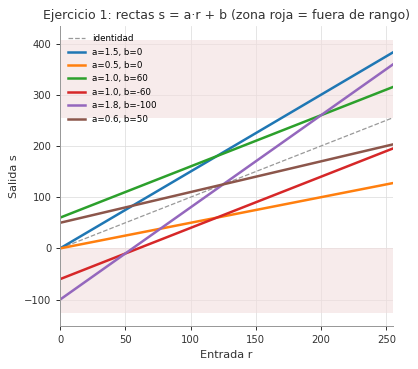

In [7]:
combinaciones = [(1.5, 0), (0.5, 0), (1.0, 60), (1.0, -60), (1.8, -100), (0.6, 50)]

curvas({f"a={a}, b={b}": a * np.arange(256) + b for a, b in combinaciones},
       titulo="Ejercicio 1: rectas s = a·r + b (zona roja = fuera de rango)")

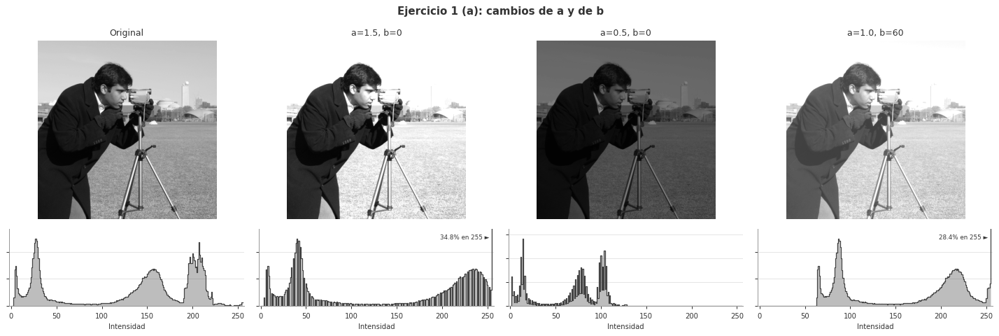

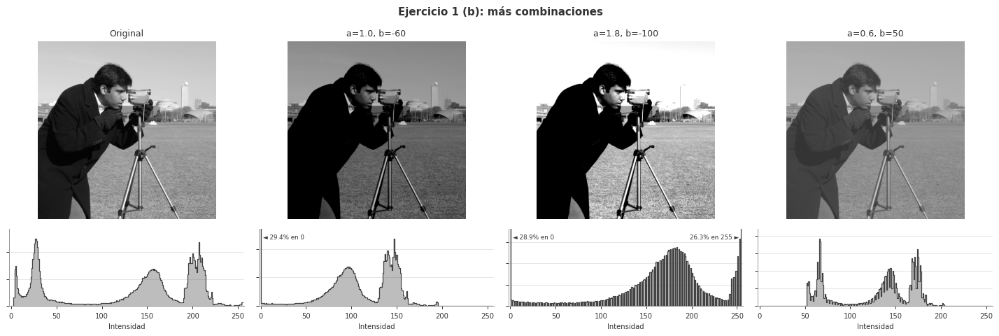

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   129.1    73.6    0  255   0.00    0.10      256
a=1.5, b=0                           I   176.5    93.9    0  255   0.00   34.83      171
a=0.5, b=0                           I    64.5    36.8    0  128   0.00    0.00      129
a=1.0, b=60                          I   185.6    69.9   60  255   0.00   28.39      196
a=1.0, b=-60                         I    79.3    59.2    0  195  29.35    0.00      196
a=1.8, b=-100                        I   143.2   103.5    0  255  28.86   26.30      143
a=0.6, b=50                          I   127.4    44.2   50  203   0.00    0.00      154


In [8]:
comparar([("Original", gris)] + [(f"a={a}, b={b}", lineal(gris, a, b)) for a, b in combinaciones[:3]],
         titulo="Ejercicio 1 (a): cambios de a y de b")
comparar([("Original", gris)] + [(f"a={a}, b={b}", lineal(gris, a, b)) for a, b in combinaciones[3:]],
         titulo="Ejercicio 1 (b): más combinaciones")

tabla([("Original", gris)] + [(f"a={a}, b={b}", lineal(gris, a, b)) for a, b in combinaciones])

### Interpretación y respuestas

**¿Cómo afecta $a$ el contraste?** En la transformación lineal \(s=ar+b\), el parámetro $a$ controla el contraste porque multiplica las diferencias entre las intensidades de los píxeles. Si \(a>1\), las diferencias aumentan y el contraste se incrementa; si \(0<a<1\), las diferencias disminuyen y el contraste se reduce. Por otro lado, $b$ controla el brillo porque desplaza todas las intensidades en una cantidad fija: \(b>0\) aclara la imagen y \(b<0\) la oscurece. Sin embargo, como las intensidades de una imagen de 8 bits solo pueden estar entre 0 y 255, los valores que superen 255 se convierten en 255 y los menores que 0 se convierten en 0, produciendo saturación y pérdida de información.


## Ejercicio 2: Saturación de valores

Se usa una transformación que produce valores fuera de $[0,255]$: $I' = 2I - 60$. El resultado sin acotar va de $-60$ a $450$. Hay dos formas de volver al rango válido:

- **Clipping:** $I'' = \min(\max(I', 0), 255)$
- **Normalización min-max:** $I'' = \dfrac{I' - \min I'}{\max I' - \min I'}\cdot 255$

Rango sin acotar: [-60, 450]
Píxeles < 0:   20.65 %
Píxeles > 255: 44.50 %


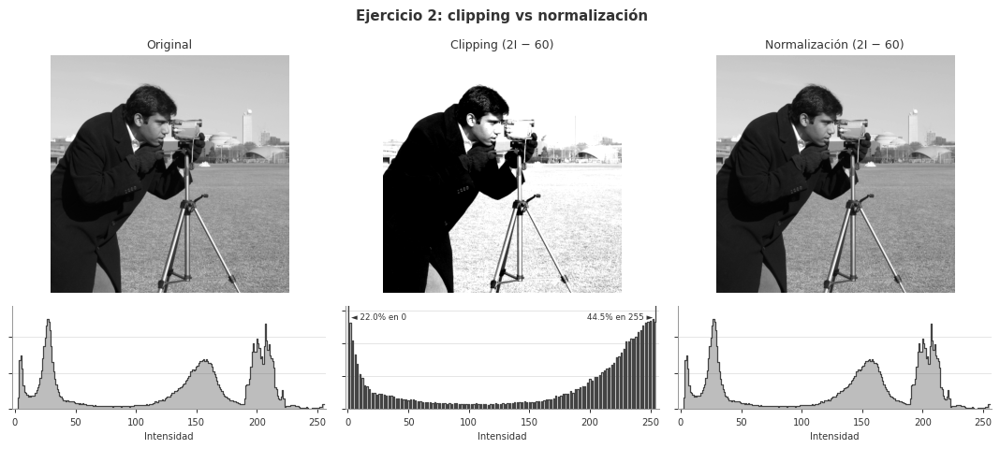

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   129.1    73.6    0  255   0.00    0.10      256
Clipping                             I   169.9   110.6    0  255  21.99   44.50      129
Normalización                        I   129.1    73.6    0  255   0.00    0.10      256

¿La normalización devuelve exactamente la original? True


In [9]:
a2, b2 = 2.0, -60
cruda = lineal(gris, a2, b2, modo=None)          # flotante, sin acotar
print(f"Rango sin acotar: [{cruda.min():.0f}, {cruda.max():.0f}]")
print(f"Píxeles < 0:   {100*(cruda < 0).mean():.2f} %")
print(f"Píxeles > 255: {100*(cruda > 255).mean():.2f} %")

clip = a_uint8(cruda, "clip")
norm = a_uint8(cruda, "norm")

comparar([("Original", gris), ("Clipping (2I − 60)", clip), ("Normalización (2I − 60)", norm)],
         titulo="Ejercicio 2: clipping vs normalización")
tabla([("Original", gris), ("Clipping", clip), ("Normalización", norm)])
print("\n¿La normalización devuelve exactamente la original?", np.array_equal(norm, gris))

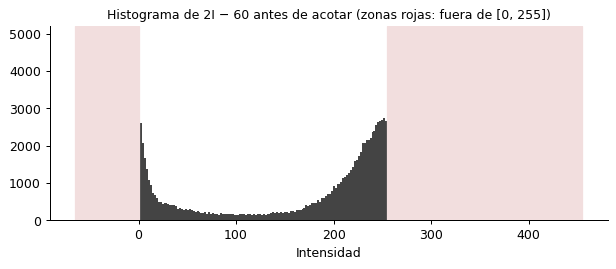

In [10]:
# Histograma del resultado SIN acotar, para ver qué parte sale del rango
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(cruda.ravel(), bins=256, color="#444444")
ax.axvspan(cruda.min() - 5, 0, color="#f2dede")
ax.axvspan(255, cruda.max() + 5, color="#f2dede")
ax.set_title("Histograma de 2I − 60 antes de acotar (zonas rojas: fuera de [0, 255])", fontsize=10)
ax.set_xlabel("Intensidad")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Segundo caso: imagen de bajo contraste.** En `bajo_contraste.png` el 97 % de los píxeles está entre 78 y 141 (percentiles 2 y 99), pero hay unos pocos píxeles en 0 y en 255. Se quiere estirar ese rango útil a $[0,255]$ con $I' = a(I - 78)$, $a = 255/63$.

Percentiles 2 y 99: 78 y 141  ->  a = 4.05, b = -316
Píxeles en 0 en la original: 240,  en 255: 4  (de 262,144)


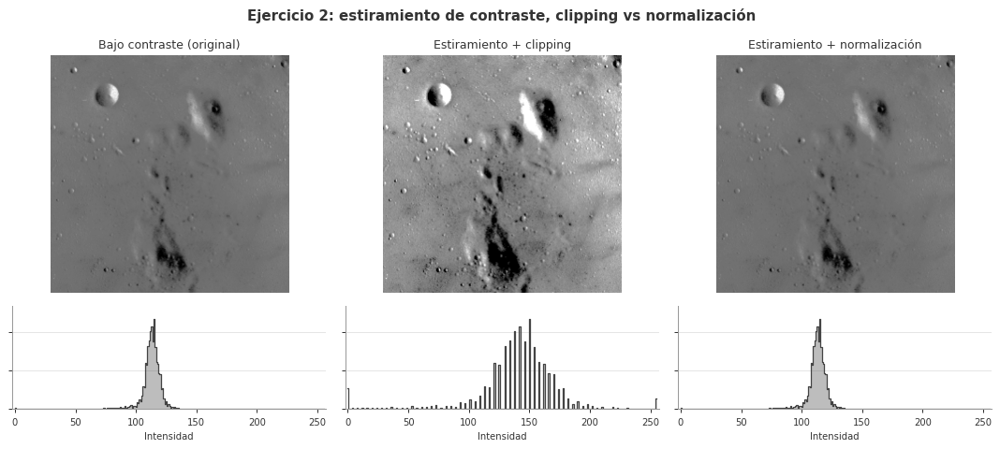

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   112.2    13.3    0  255   0.09    0.00      178
Clipping                             I   139.6    35.9    0  255   2.02    1.00       64
Normalización                        I   112.2    13.3    0  255   0.09    0.00      178

¿La normalización devuelve exactamente la original? True


In [12]:
p2, p99 = np.percentile(luna, [2, 99])
a_luna = 255 / (p99 - p2)
cruda_luna = lineal(luna, a_luna, -a_luna * p2, modo=None)
print(f"Percentiles 2 y 99: {p2:.0f} y {p99:.0f}  ->  a = {a_luna:.2f}, b = {-a_luna * p2:.0f}")
print(f"Píxeles en 0 en la original: {(luna == 0).sum()},  en 255: {(luna == 255).sum()}  (de {luna.size:,})")

luna_clip = a_uint8(cruda_luna, "clip")
luna_norm = a_uint8(cruda_luna, "norm")
comparar([("Bajo contraste (original)", luna), ("Estiramiento + clipping", luna_clip),
          ("Estiramiento + normalización", luna_norm)],
         titulo="Ejercicio 2: estiramiento de contraste, clipping vs normalización")
tabla([("Original", luna), ("Clipping", luna_clip), ("Normalización", luna_norm)])
print("\n¿La normalización devuelve exactamente la original?", np.array_equal(luna_norm, luna))

### Interpretación y respuesta
El clipping aplica la transformación y conserva los valores que quedan dentro de \(0\) y \(255\), pero todos los valores menores que 0 se convierten en 0 y los mayores que 255 se convierten en 255. Esto provoca pérdida de información porque diferentes intensidades terminan teniendo el mismo valor, por lo que el histograma presenta grandes acumulaciones en 0 y 255. En cambio, la normalización min-max reescala los valores desde el mínimo y máximo reales de la imagen hasta el rango \(0\)-\(255\), sin saturar los valores. Sin embargo, es sensible a valores extremos: si existen pocos píxeles con valores muy bajos o muy altos, estos determinan el rango y hacen que la mayoría de los píxeles quede comprimida en una pequeña parte de \(0\)-\(255\), reduciendo el contraste. En el caso de la luna, el clipping permite aumentar el contraste de la mayoría de los píxeles y revelar detalles, mientras que la normalización se ve afectada por los valores extremos y no produce la misma mejora.

## Ejercicio 3: Transformación por tramos

Se define una función lineal por partes con tres tramos, a través de los puntos de control $(0,0)$, $(85,40)$, $(170,215)$, $(255,255)$:

| Tramo | Entrada $r$ | Pendiente | Efecto |
|---|---|---|---|
| Bajas | $0 \le r < 85$ | $40/85 \approx 0.47$ | oscurece (salida por debajo de la identidad) |
| Medias | $85 \le r < 170$ | $175/85 \approx 2.06$ | mantiene el centro ($r=127.5 \to s=127.5$) y expande |
| Altas | $170 \le r \le 255$ | $40/85 \approx 0.47$ | aclara (salida por encima de la identidad) |

La curva cruza la identidad justo en el punto medio, así que los tonos medios quedan en su sitio, los bajos se hunden y los altos suben.

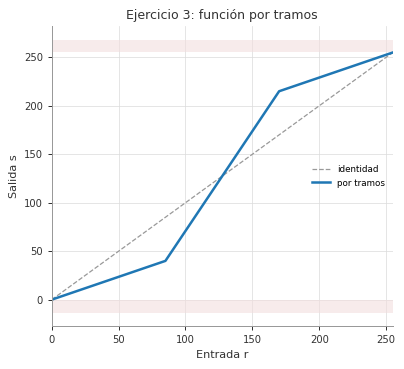

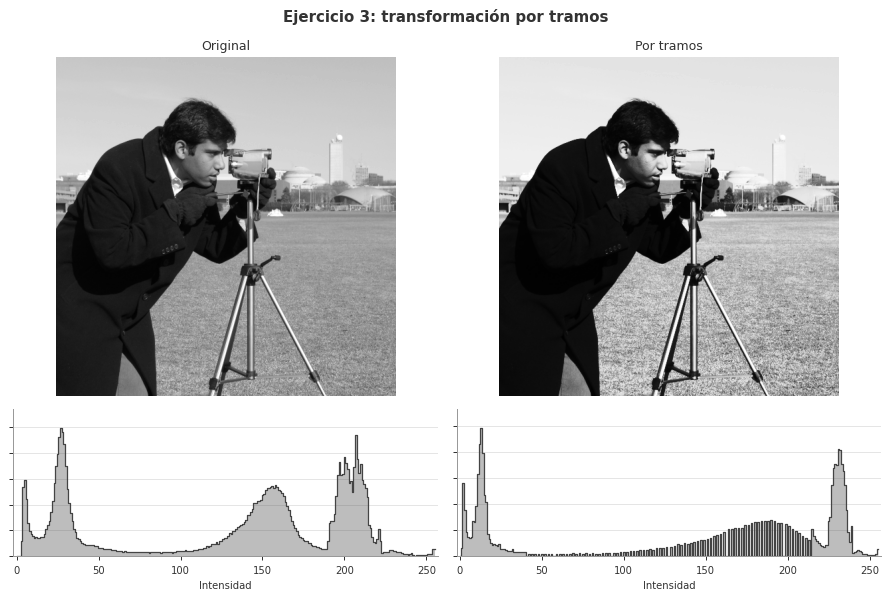

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   129.1    73.6    0  255   0.00    0.10      256
Por tramos                           I   140.9    92.3    0  255   0.00    0.22      166

Media de píxeles originalmente oscuros (<85):  27.5 -> 12.9
Media de píxeles originalmente medios (85-169): 145.9 -> 165.3
Media de píxeles originalmente claros (>=170): 202.8 -> 230.4


In [13]:
puntos = [(0, 0), (85, 40), (170, 215), (255, 255)]
r_, s_ = zip(*puntos)
curvas({"por tramos": np.interp(np.arange(256), r_, s_)},
       titulo="Ejercicio 3: función por tramos")

tramos = por_tramos(gris, puntos)
comparar([("Original", gris), ("Por tramos", tramos)], titulo="Ejercicio 3: transformación por tramos", ancho=5)
tabla([("Original", gris), ("Por tramos", tramos)])

bajos_o = (gris < 85).mean() * 100; bajos_t = (tramos < 40).mean() * 100
print(f"\nMedia de píxeles originalmente oscuros (<85):  {gris[gris < 85].mean():.1f} -> {tramos[gris < 85].mean():.1f}")
print(f"Media de píxeles originalmente medios (85-169): {gris[(gris >= 85) & (gris < 170)].mean():.1f} -> {tramos[(gris >= 85) & (gris < 170)].mean():.1f}")
print(f"Media de píxeles originalmente claros (>=170): {gris[gris >= 170].mean():.1f} -> {tramos[gris >= 170].mean():.1f}")

### Interpretación y respuesta
La curva en S aumenta el contraste de la imagen al comprimir los tonos extremos y expandir los tonos medios. Los píxeles oscuros y claros tienen una pendiente aproximada de \(0.47<1\), por lo que sus valores se acercan a 0 y 255, mientras que la zona central tiene una pendiente de \(2.06>1\), por lo que las diferencias entre los tonos medios aumentan. El punto medio \(127.5\) permanece fijo. Como resultado, la desviación estándar aumenta de 73.6 a 92.3, indicando un mayor contraste global. A diferencia de una transformación lineal con \(a>1\), la curva en S produce muy poca saturación: solo el 0.22 % de los píxeles llega a 255. Sin embargo, se pierde cierta información en los extremos porque sus tonos se comprimen, quedando 166 niveles distintos.


## Ejercicio 4: Inversión de intensidades

$$I' = 255 - I$$

Se aplica a la imagen de prueba y a la versión en gris de la imagen oscura, donde predominan las zonas negras.

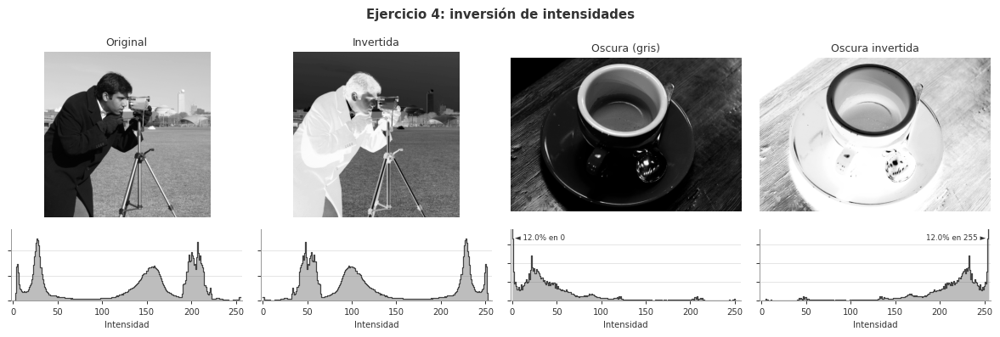

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   129.1    73.6    0  255   0.00    0.10      256
Invertida                            I   125.9    73.6    0  255   0.10    0.00      256
Oscura (gris)                        I    42.9    46.7    0  255  12.02    0.00      256
Oscura invertida                     I   212.1    46.7    0  255   0.00   12.02      256

¿El histograma invertido es el original reflejado (h'[k] = h[255-k])? True


In [14]:
oscura_gris = a_gris(oscura)
inv = inversion(gris)
inv_osc = inversion(oscura_gris)
comparar([("Original", gris), ("Invertida", inv), ("Oscura (gris)", oscura_gris), ("Oscura invertida", inv_osc)],
         titulo="Ejercicio 4: inversión de intensidades", ancho=3.3)
tabla([("Original", gris), ("Invertida", inv), ("Oscura (gris)", oscura_gris), ("Oscura invertida", inv_osc)])

h_o = np.bincount(gris.ravel(), minlength=256)
h_i = np.bincount(inv.ravel(), minlength=256)
print("\n¿El histograma invertido es el original reflejado (h'[k] = h[255-k])?", np.array_equal(h_i, h_o[::-1]))

### Interpretación y respuestas
La inversión de intensidad cambia cada píxel según \(s=255-r\), por lo que el histograma se refleja horizontalmente alrededor de 127.5: los píxeles con valor \(k\) pasan a tener valor \(255-k\). Por eso la media cambia de \(\mu\) a \(255-\mu\), mientras que la desviación estándar permanece igual, ya que las distancias entre los valores no cambian. La inversión tampoco pierde información porque es reversible: al aplicarla dos veces se recupera la imagen original. Esta transformación es útil cuando los detalles importantes son claros sobre fondos oscuros, porque permite hacer más visibles esas variaciones de intensidad. Por ejemplo, puede utilizarse en radiografías, imágenes astronómicas, microscopía y negativos fotográficos.


---
# Parte 2: Transformaciones no lineales (Gamma)

## Ejercicio 5: Corrección gamma

$$I' = c\cdot I^{\gamma}$$

Para que el resultado quede en $[0,255]$ la fórmula se aplica sobre intensidades normalizadas: $I' = 255\cdot c\cdot (I/255)^{\gamma}$, con $c=1$. Así $0 \to 0$ y $255 \to 255$ para cualquier $\gamma$; solo cambia **cómo** se reparten los valores intermedios.

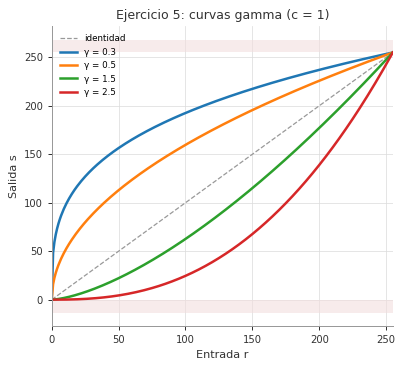

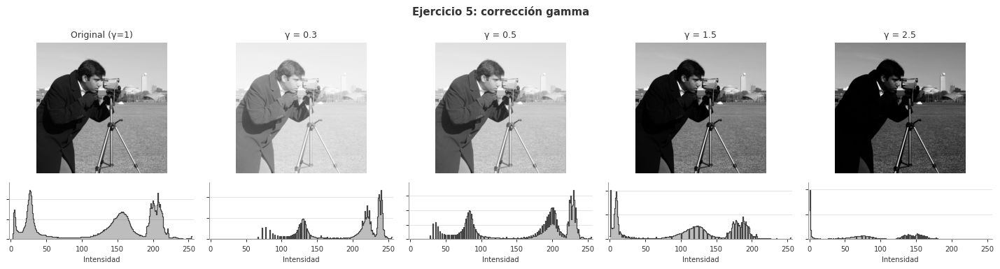

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             I   129.1    73.6    0  255   0.00    0.10      256
γ = 0.3                              I   195.5    49.8    0  255   0.00    0.22      149
γ = 0.5                              I   169.8    63.8    0  255   0.00    0.10      192
γ = 1.5                              I   104.2    71.3    0  255   0.24    0.10      218
γ = 2.5                              I    73.1    60.9    0  255   8.76    0.10      173


In [15]:
gammas = [0.3, 0.5, 1.5, 2.5]
curvas({f"γ = {g}": curva_gamma(g) for g in gammas}, titulo="Ejercicio 5: curvas gamma (c = 1)")

comparar([("Original (γ=1)", gris)] + [(f"γ = {g}", gamma(gris, g)) for g in gammas],
         titulo="Ejercicio 5: corrección gamma", ancho=3.2)
tabla([("Original", gris)] + [(f"γ = {g}", gamma(gris, g)) for g in gammas])

In [16]:
# Pendiente de la curva (derivada) en zonas oscuras y claras: cuánto se "estira" cada rango
print("Pendiente ds/dr = γ·(r/255)^(γ-1)")
print(f"{'γ':>5}{'r = 20 (sombra)':>18}{'r = 128 (medio)':>18}{'r = 235 (luz)':>16}")
for g in gammas:
    d = [g * (r / 255) ** (g - 1) for r in (20, 128, 235)]
    print(f"{g:>5}{d[0]:>18.2f}{d[1]:>18.2f}{d[2]:>16.2f}")

Pendiente ds/dr = γ·(r/255)^(γ-1)
    γ   r = 20 (sombra)   r = 128 (medio)   r = 235 (luz)
  0.3              1.78              0.49            0.32
  0.5              1.79              0.71            0.52
  1.5              0.42              1.06            1.44
  2.5              0.05              0.89            2.21


### Interpretación y respuesta

La transformación gamma se usa para redistribuir los niveles de intensidad de acuerdo con la función \(s=255(r/255)^\gamma\). Cuando \(\gamma<1\), la curva queda por encima de la identidad, por lo que los tonos oscuros se expanden y los claros se comprimen: la imagen se aclara, aparecen detalles en las sombras y disminuye el contraste en las zonas claras. Cuando \(\gamma>1\), ocurre lo contrario: los tonos oscuros se comprimen hacia el negro y los claros se expanden, por lo que la imagen se oscurece y se resaltan detalles en las zonas claras. La pendiente de la curva indica dónde se están separando o juntando los niveles: una pendiente mayor que 1 aumenta las diferencias entre tonos y una menor que 1 las reduce. A diferencia de una transformación lineal, la gamma mantiene los extremos 0 y 255 y, con \(c=1\), no produce saturación por recorte; únicamente redistribuye los valores intermedios.


## Ejercicio 6: Gamma vs transformación lineal

Se busca la recta $s = a r + b$ que mejor aproxima la curva gamma con **mínimos cuadrados** sobre los 256 niveles de entrada. Se hace para $\gamma = 0.5$ (aclarar) y $\gamma = 2.0$ (oscurecer).

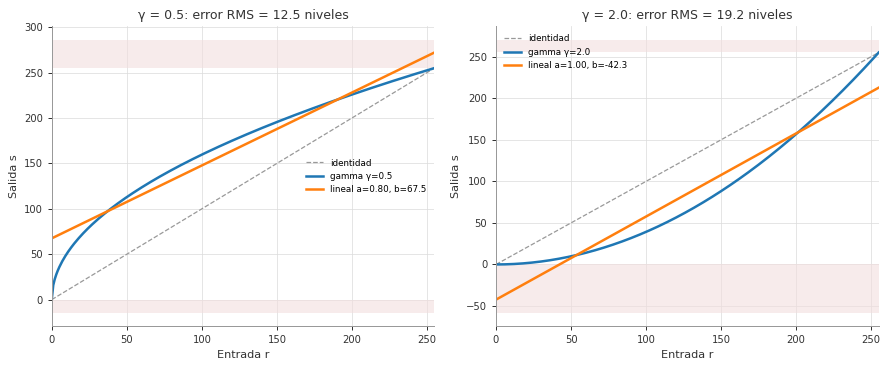

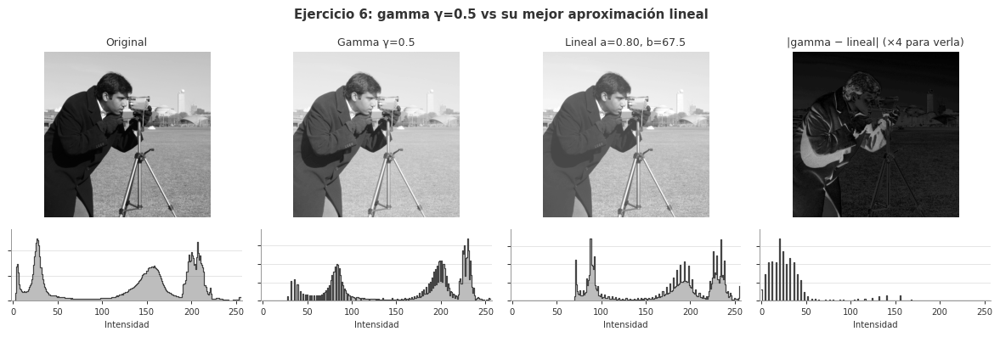

γ=0.5: diferencia media = 7.4, máxima = 67 niveles


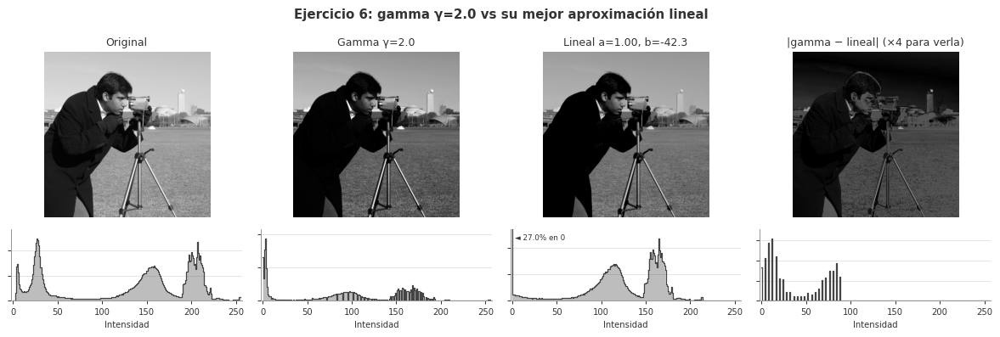

γ=2.0: diferencia media = 9.5, máxima = 42 niveles


In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4.2))
aprox = {}
for ax, g in zip(ejes, [0.5, 2.0]):
    a_, b_, rms = ajuste_lineal_a_gamma(g)
    aprox[g] = (a_, b_, rms)
    curvas({f"gamma γ={g}": curva_gamma(g), f"lineal a={a_:.2f}, b={b_:.1f}": a_ * np.arange(256) + b_},
           titulo=f"γ = {g}: error RMS = {rms:.1f} niveles", ax=ax)
fig.tight_layout()
plt.show()

for g, (a_, b_, rms) in aprox.items():
    img_g = gamma(gris, g)
    img_l = lineal(gris, a_, b_)
    dif = np.abs(img_g.astype(int) - img_l.astype(int))
    comparar([("Original", gris), (f"Gamma γ={g}", img_g), (f"Lineal a={a_:.2f}, b={b_:.1f}", img_l),
              ("|gamma − lineal| (×4 para verla)", np.clip(dif * 4, 0, 255).astype(np.uint8))],
             titulo=f"Ejercicio 6: gamma γ={g} vs su mejor aproximación lineal", ancho=3.3)
    print(f"γ={g}: diferencia media = {dif.mean():.1f}, máxima = {dif.max()} niveles")

### Interpretación y respuesta
**### Interpretación y respuesta**

La transformación gamma no puede representarse exactamente mediante una transformación lineal porque una recta tiene una **pendiente constante**, mientras que la curva gamma tiene una pendiente que cambia según el valor de intensidad. Esto significa que una transformación lineal modifica el contraste de todos los tonos de manera uniforme, mientras que gamma puede aumentar el contraste en unas zonas y reducirlo en otras. Por ejemplo, con $\gamma<1$, gamma expande las sombras y comprime las luces; con $\gamma>1$, hace lo contrario. Por eso una recta puede aproximar una curva gamma, pero siempre tendrá errores, especialmente en los extremos del rango. Solo cuando $\gamma=1$ ambas transformaciones son exactamente iguales, ya que la función gamma se convierte en $s=r$.


## Ejercicio 7: Mejora de imágenes oscuras

Se toma `oscura.png` (brillo medio ≈ 43 sobre 255; el 62 % de los píxeles está por debajo de 40, pero los reflejos de la taza siguen cerca de 255) y se comparan tres mejoras:

1. **Lineal sin saturar:** la mayor ganancia $I' = aI$ que no satura ningún píxel, $a = 255/\max(I)$.
2. **Lineal con el mismo brillo que la gamma:** $I' = aI$ con $a$ elegida para que el brillo medio llegue a 120 (con clipping).
3. **Gamma:** $I' = 255(I/255)^{\gamma}$ con $\gamma$ elegida para que el brillo medio también llegue a 120.

Igualar el brillo medio hace que la comparación entre (2) y (3) sea justa. El detalle se mide con la desviación estándar (contraste local) dentro de dos regiones definidas sobre la imagen **original**: **sombras** (gris < 40) y **luces** (gris ≥ 110).

Lineal sin saturar: a = 1.00   Lineal mismo brillo: a = 6.08   Gamma: γ = 0.238


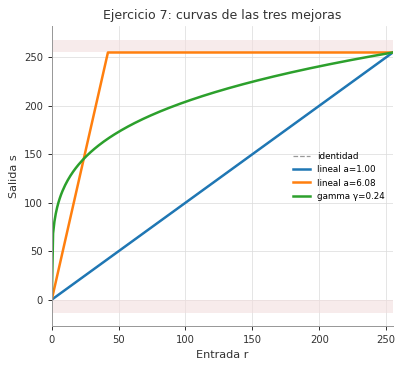

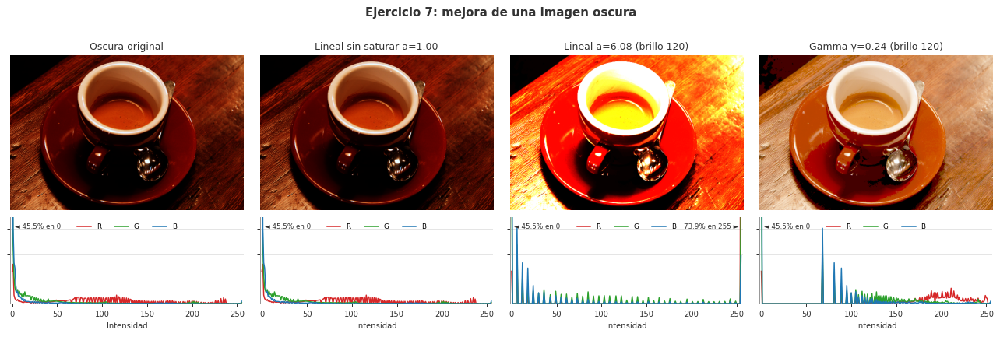

In [18]:
objetivo = 120.0

def buscar(funcion, lo, hi, creciente=True):
    """Bisección: encuentra el parámetro con el que el brillo medio llega al objetivo."""
    for _ in range(60):
        m = (lo + hi) / 2
        if (a_gris(funcion(m)).mean() < objetivo) == creciente:
            lo = m
        else:
            hi = m
    return (lo + hi) / 2

a_max = 255 / oscura.max()
a7 = buscar(lambda a: lineal(oscura, a, 0), 1, 20, creciente=True)
g7 = buscar(lambda g: gamma(oscura, g), 0.05, 1, creciente=False)
lin_sin_sat = lineal(oscura, a_max, 0)
mej_lin = lineal(oscura, a7, 0)
mej_gam = gamma(oscura, g7)
print(f"Lineal sin saturar: a = {a_max:.2f}   Lineal mismo brillo: a = {a7:.2f}   Gamma: γ = {g7:.3f}")

curvas({f"lineal a={a_max:.2f}": np.clip(a_max * np.arange(256), 0, 255),
        f"lineal a={a7:.2f}": np.clip(a7 * np.arange(256), 0, 255),
        f"gamma γ={g7:.2f}": curva_gamma(g7)},
       titulo="Ejercicio 7: curvas de las tres mejoras")

resultados7 = [("Oscura original", oscura), (f"Lineal sin saturar a={a_max:.2f}", lin_sin_sat),
               (f"Lineal a={a7:.2f} (brillo 120)", mej_lin), (f"Gamma γ={g7:.2f} (brillo 120)", mej_gam)]
comparar(resultados7, titulo="Ejercicio 7: mejora de una imagen oscura", ancho=3.6)

Sombras: 61.8 % de la imagen   Luces: 8.3 % de la imagen

método                     brillo medio  desv sombras  desv luces   % píxeles con algún canal en 255
Oscura original                    42.9          12.9        42.0                                0.4
Lineal sin saturar a=1.00          42.9          12.9        42.0                                0.4
Lineal a=6.08 (brillo 120)        120.0          45.9         1.8                               73.9
Gamma γ=0.24 (brillo 120)         120.0          48.6        15.1                                0.4


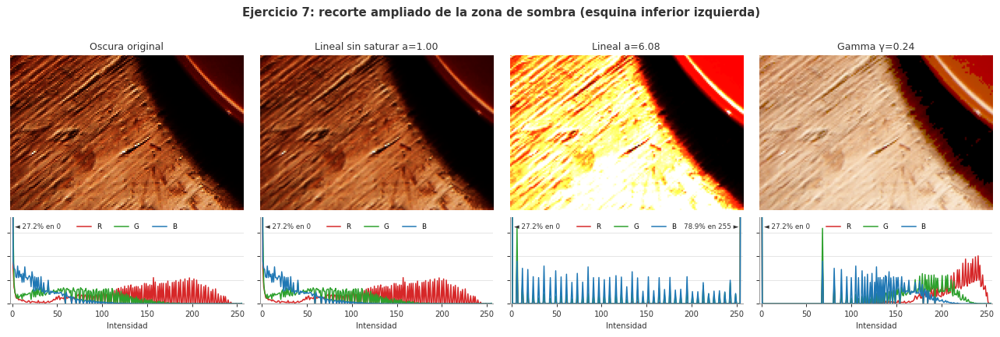

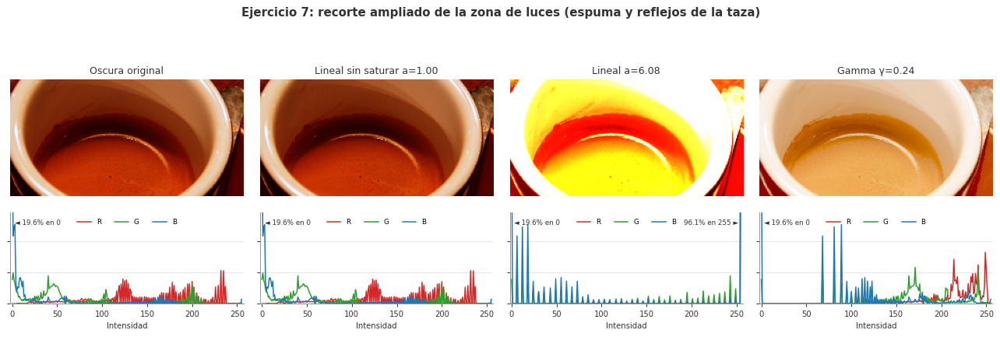

In [19]:
g_orig = a_gris(oscura)
sombras, luces = g_orig < 40, g_orig >= 110
print(f"Sombras: {100 * sombras.mean():.1f} % de la imagen   Luces: {100 * luces.mean():.1f} % de la imagen\n")
print(f"{'método':<26}{'brillo medio':>13}{'desv sombras':>14}{'desv luces':>12}{'% píxeles con algún canal en 255':>35}")
for nombre, img in resultados7:
    g_ = a_gris(img)
    sat = 100 * (img == 255).any(axis=-1).mean()
    print(f"{nombre:<26}{g_.mean():>13.1f}{g_[sombras].std():>14.1f}{g_[luces].std():>12.1f}{sat:>35.1f}")

# Recortes ampliados: una zona de sombra y una zona de luces
zonas = {"sombra (esquina inferior izquierda)": (300, 400, 0, 150),
         "luces (espuma y reflejos de la taza)": (60, 180, 180, 420)}
for nombre, (y0, y1, x0, x1) in zonas.items():
    comparar([(t.split(" (")[0], img[y0:y1, x0:x1]) for t, img in resultados7],
             titulo=f"Ejercicio 7: recorte ampliado de la zona de {nombre}", ancho=3.6)

**### Interpretación y respuesta**

La transformación lineal sin saturar, con $a=1.00$, no puede aumentar el brillo porque la imagen ya contiene píxeles con valor 255. Aumentar $a$ haría que más píxeles superaran 255 y se saturaran. Para alcanzar un brillo medio de 120 mediante una transformación lineal, se necesita $a=6.08$, lo que provoca una saturación del 73.9 % de los píxeles y hace que se pierdan detalles en las zonas claras. Además, la saturación de los canales de color modifica los tonos originales. En cambio, la corrección gamma con $\gamma=0.24$ permite aumentar el brillo de las sombras sin saturar significativamente las luces, conservando mejor detalles como la espuma y el borde de la taza. Por esto, la **corrección gamma con $\gamma<1$** conserva mejor los detalles en las sombras, ya que aumenta las diferencias entre los tonos oscuros y comprime las luces. Sin embargo, gamma no crea información nueva: también puede amplificar el ruido y los efectos de cuantización presentes en las sombras.


---
# Parte 3: Transformaciones en imágenes RGB

En una imagen RGB cada píxel tiene tres valores (R, G, B). Las transformaciones anteriores se pueden aplicar a cada canal por separado, lo que permite cambiar además del brillo y el contraste, **el color**. Los histogramas de esta parte muestran una curva por canal (rojo, verde, azul).

## Ejercicio 8: Transformación lineal independiente por canal

$$R' = a_R R + b_R,\quad G' = a_G G + b_G,\quad B' = a_B B + b_B$$

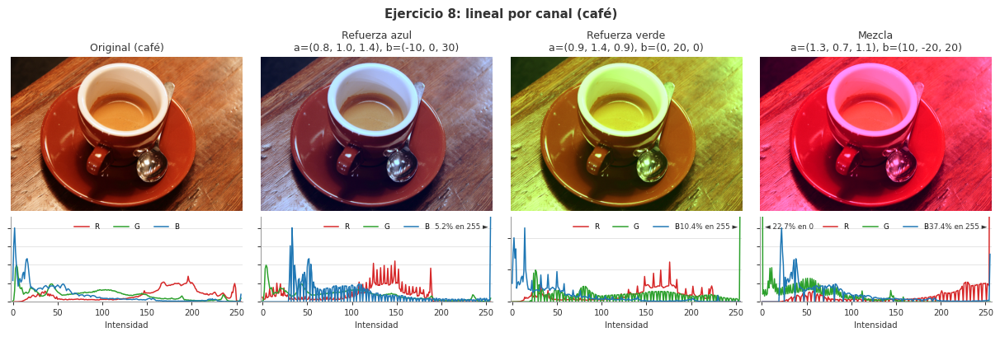

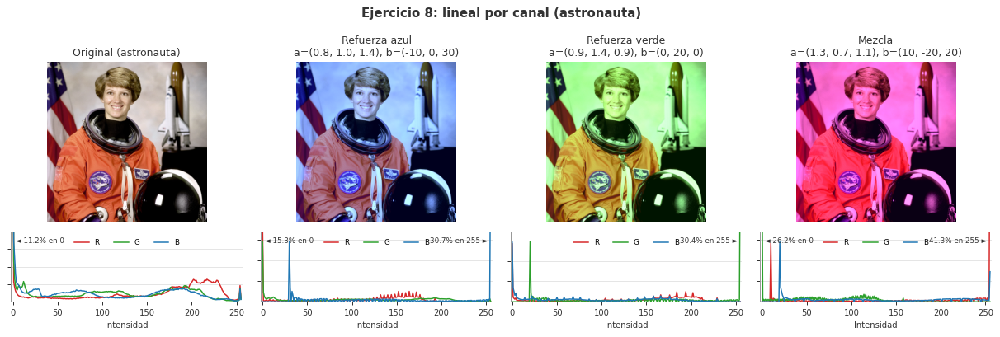

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original café                        R   158.6    63.0    0  255   0.00    0.01      253
Original café                        G    85.8    61.0    0  255   0.05    0.20      256
Original café                        B    51.5    52.9    0  255   1.20    0.42      256
Refuerza azul                        R   116.9    50.4    0  194   0.26    0.00      195
Refuerza azul                        G    85.8    61.0    0  255   0.05    0.20      256
Refuerza azul                        B    98.5    63.8   30  255   0.00    5.19      162
Refuerza verde                       R   142.7    56.7    0  230   0.00    0.00      229
Refuerza verde                       G   134.7    74.7   20  255   0.00   10.44      169
Refuerza verde                       B    46.4    47.6    0  230   1.20    0.00      231
Mezcla               

In [20]:
config8 = {
    "Refuerza azul":  ((0.8, 1.0, 1.4), (-10, 0, 30)),
    "Refuerza verde": ((0.9, 1.4, 0.9), (0, 20, 0)),
    "Mezcla": ((1.3, 0.7, 1.1), (10, -20, 20)),
}
for img_nombre, img in [("café", cafe), ("astronauta", astro)]:
    res = [(f"{k}\na={v[0]}, b={v[1]}", lineal_canales(img, *v)) for k, v in config8.items()]
    comparar([(f"Original ({img_nombre})", img)] + res, titulo=f"Ejercicio 8: lineal por canal ({img_nombre})", ancho=3.4)

tabla([("Original café", cafe)] + [(k, lineal_canales(cafe, *v)) for k, v in config8.items()])

**### Interpretación y respuestas**

Al utilizar parámetros diferentes para cada canal RGB, la transformación modifica no solo el brillo, sino también el **color** de la imagen, porque cambia la proporción entre R, G y B. Si se aumenta un canal, ese color se vuelve más dominante, mientras que reducir otro hace que su contribución disminuya. Por ejemplo, al reforzar el azul, la media de B aumenta de 51 a 99 y la de R disminuye de 159 a 117, haciendo que la imagen adquiera un tono más azulado o violeta. Al reforzar el verde, la imagen adquiere una tonalidad verdosa o amarillenta, mientras que al aumentar el rojo y el azul y reducir el verde, la imagen tiende hacia el magenta. Además, los píxeles grises dejan de ser grises porque sus tres canales ya no mantienen el mismo valor. El canal que domina la apariencia final depende de cuál tenga mayor intensidad relativa después de la transformación, aunque también influye el contenido original de la imagen. En cuanto al brillo percibido, el verde tiene mayor peso que el rojo y el azul, por lo que un cambio igual en G produce un cambio visual de brillo mayor que el mismo cambio en B.


## Ejercicio 9: Transformación sobre un solo canal

$$R' = aR + b,\quad G' = G,\quad B' = B$$

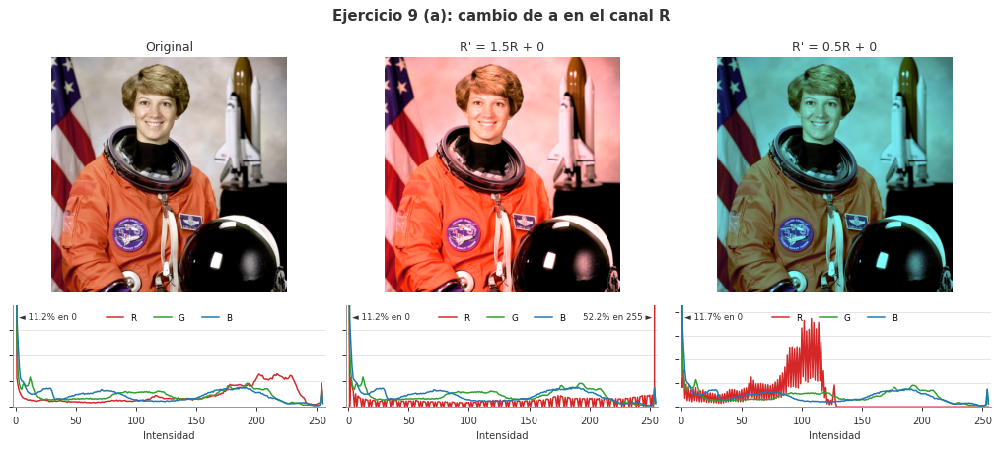

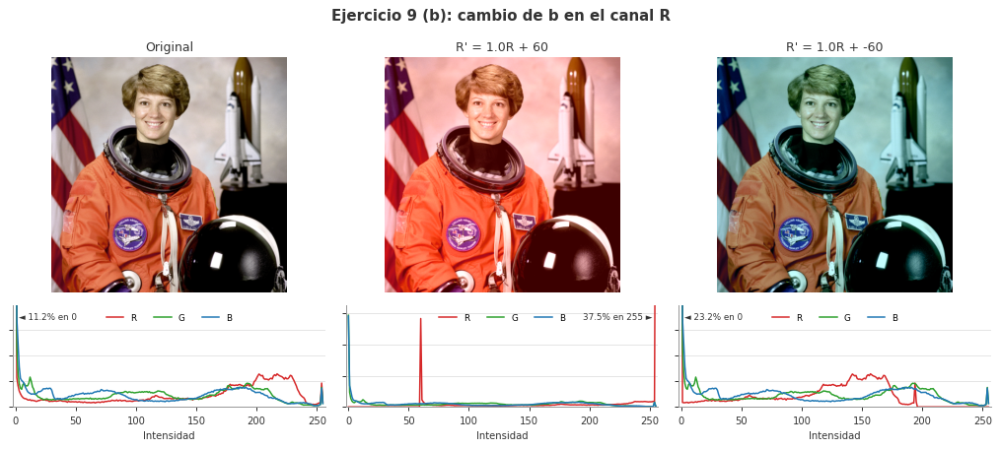

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             R   141.6    82.0    0  255  10.81    0.15      256
Original                             G   105.8    76.6    0  255  11.21    0.11      256
Original                             B    96.5    77.9    0  255  11.10    0.10      256
R' = 1.5R + 0                        R   182.7    97.9    0  255  10.81   52.23      171
R' = 1.5R + 0                        G   105.8    76.6    0  255  11.21    0.11      256
R' = 1.5R + 0                        B    96.5    77.9    0  255  11.10    0.10      256
R' = 0.5R + 0                        R    70.8    41.0    0  128  11.67    0.00      129
R' = 0.5R + 0                        G   105.8    76.6    0  255  11.21    0.11      256
R' = 0.5R + 0                        B    96.5    77.9    0  255  11.10    0.10      256
R' = 1.0R + 60       

In [21]:
config9 = [(1.5, 0), (0.5, 0), (1.0, 60), (1.0, -60)]
res9 = [(f"R' = {a}R + {b}", lineal_canales(astro, (a, 1, 1), (b, 0, 0))) for a, b in config9]
comparar([("Original", astro)] + res9[:2], titulo="Ejercicio 9 (a): cambio de a en el canal R", ancho=3.8)
comparar([("Original", astro)] + res9[2:], titulo="Ejercicio 9 (b): cambio de b en el canal R", ancho=3.8)
tabla([("Original", astro)] + res9)

In [22]:
# Efecto sobre el color de algunos píxeles: tono (H) y saturación (S) en el espacio HSV
import cv2
muestras = {"gris neutro": [128, 128, 128], "azul (traje)": [60, 90, 170], "piel": [200, 150, 120]}
print(f"{'píxel':<14}{'RGB original':>17}{'RGB con 1.5R':>17}{'H orig':>8}{'H nuevo':>9}{'S orig':>8}{'S nuevo':>9}")
for nombre, rgb in muestras.items():
    p = np.array([[rgb]], dtype=np.uint8)
    q = lineal_canales(p, (1.5, 1, 1), (0, 0, 0))
    hp, sp, _ = cv2.cvtColor(p, cv2.COLOR_RGB2HSV)[0, 0]
    hq, sq, _ = cv2.cvtColor(q, cv2.COLOR_RGB2HSV)[0, 0]
    print(f"{nombre:<14}{str(rgb):>17}{str(q[0, 0].tolist()):>17}{int(hp) * 2:>7}°{int(hq) * 2:>8}°"
          f"{int(sp) / 2.55:>7.0f}%{int(sq) / 2.55:>8.0f}%")

píxel              RGB original     RGB con 1.5R  H orig  H nuevo  S orig  S nuevo
gris neutro     [128, 128, 128]  [192, 128, 128]      0°       0°      0%      33%
azul (traje)      [60, 90, 170]    [90, 90, 170]    224°     240°     65%      47%
piel            [200, 150, 120]  [255, 150, 120]     22°      14°     40%      53%


### Interpretación y respuestas

**¿Cómo cambia la tonalidad?** Al modificar solo R, cambia la proporción de rojo frente a verde y azul en cada píxel, y con ella el **tono**:
- Con $a=1.5$ o $b=60$ la imagen **se vuelve rojiza**: la piel pasa a naranja-rojo, los blancos (casco, transbordador) a rosado y el fondo gris a salmón. La tabla HSV lo muestra: un gris neutro (saturación 0 %) pasa a tener 33 % de saturación hacia el rojo; la piel se desplaza de 22° a 14° (más hacia el rojo puro, 0°); el azul del traje pasa de 224° a 240°: al añadir rojo a un azul verdoso se acerca al azul-violeta.
- Con $a=0.5$ o $b=-60$ ocurre lo contrario: la imagen toma el color complementario del rojo, el **cian** (verde + azul). Los blancos se vuelven cian claro y la piel se ve verdosa y sin vida.

**¿Qué ocurre si $a>1$ o $b>0$?**
- **$a > 1$** multiplica el rojo: el efecto es **proporcional**. Los píxeles con poco rojo (negros, azules) casi no cambian (0·1.5 = 0), mientras que los que ya tenían mucho rojo (traje naranja, piel) se saturan: el 52 % de los píxeles termina con R = 255. Además aumenta el contraste solo del canal rojo (desv 82 → 98).
- **$b > 0$** suma lo mismo a todos: el efecto es **uniforme**. Incluso los negros pasan a tener R = 60 (el 0 % en R = 0 lo confirma: antes era 10.8 %), así que las sombras y el fondo negro del espacio se tiñen de rojo oscuro. Es como un velo rojo encima de toda la imagen. El histograma del canal R se desplaza completo 60 niveles a la derecha y 37.5 % queda saturado.
- En los dos casos los histogramas de G y B no cambian en absoluto: todo el cambio de color viene de mover el histograma rojo respecto a los otros dos.

## Ejercicio 10: Eliminación de un canal

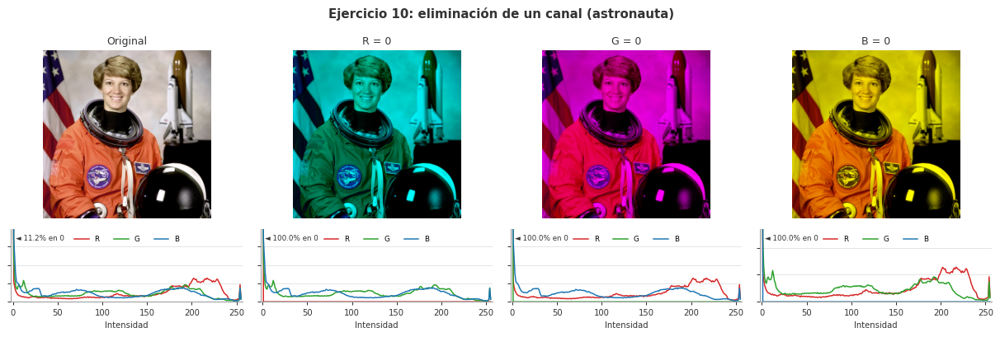

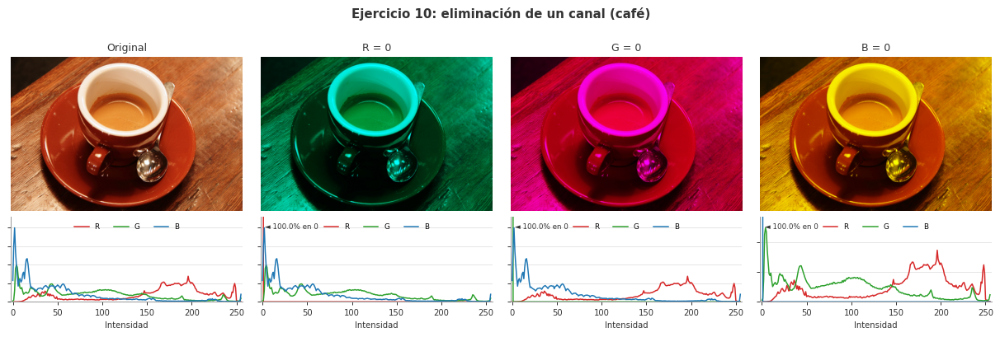

In [23]:
for img_nombre, img in [("astronauta", astro), ("café", cafe)]:
    comparar([("Original", img)] + [(f"{c} = 0", eliminar_canal(img, c)) for c in "RGB"],
             titulo=f"Ejercicio 10: eliminación de un canal ({img_nombre})", ancho=3.4)

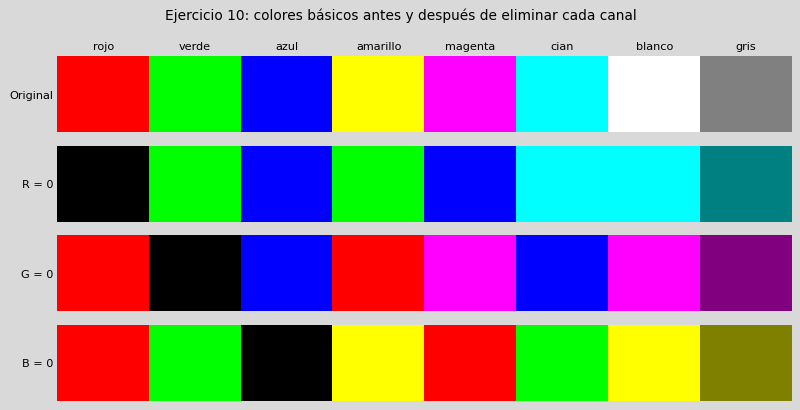

In [24]:
# Qué pasa con los colores puros y secundarios al eliminar R
paleta = np.array([[[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
                    [255, 0, 255], [0, 255, 255], [255, 255, 255], [128, 128, 128]]], dtype=np.uint8)
nombres = ["rojo", "verde", "azul", "amarillo", "magenta", "cian", "blanco", "gris"]
fig, ejes = plt.subplots(4, 1, figsize=(9, 4.6), facecolor="#d9d9d9")
for ax, (t, p) in zip(ejes, [("Original", paleta)] + [(f"{c} = 0", eliminar_canal(paleta, c)) for c in "RGB"]):
    ax.imshow(p, aspect="auto")
    ax.set_yticks([0]); ax.set_yticklabels([t], fontsize=9)
    ax.set_xticks(range(len(nombres))); ax.set_xticklabels(nombres if t == "Original" else [], fontsize=9)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
ejes[0].xaxis.tick_top()
fig.suptitle("Ejercicio 10: colores básicos antes y después de eliminar cada canal", fontsize=11)
fig.tight_layout()
plt.show()

**### Interpretación y respuestas**

Fijar un canal en 0 equivale a bloquear completamente ese color primario, eliminando toda su contribución en la imagen. Si $R=0$, el rojo puro se vuelve negro, el amarillo se vuelve verde, el magenta se vuelve azul, el blanco se vuelve cian y el gris se vuelve cian oscuro. En el astronauta, $R=0$ hace que el traje naranja se vuelva verde oscuro y la piel verde grisácea; las franjas rojas de la bandera quedan negras. Con $G=0$ la imagen adquiere tonos magenta y con $B=0$ tonos amarillos. En el café, al eliminar R, la madera, el plato y el líquido quedan verde-azulados muy oscuros y la taza blanca se vuelve cian; al eliminar B, la madera y el plato cambian poco porque ese canal aportaba poco, mientras que la taza blanca se vuelve amarilla. Solo permanecen las combinaciones que pueden formarse con los dos canales restantes: con $R=0$ quedan verde, azul y cian; con $G=0$ quedan rojo, azul y magenta; y con $B=0$ quedan rojo, verde y amarillo, conservando sus diferentes intensidades. Por tanto, el espacio de colores representable pasa de un cubo a una de sus caras y ya no pueden representarse el blanco ni los grises neutros.


## Ejercicio 11: Corrección gamma por canal

$$R' = 255 (R/255)^{\gamma_R},\quad G' = 255 (G/255)^{\gamma_G},\quad B' = 255 (B/255)^{\gamma_B}$$

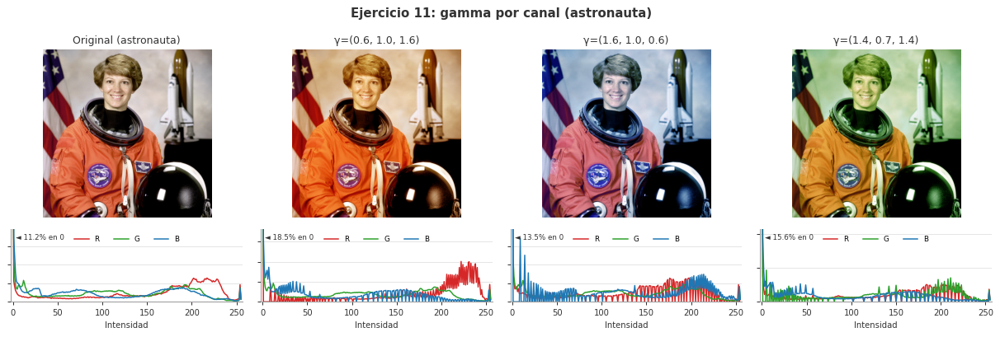

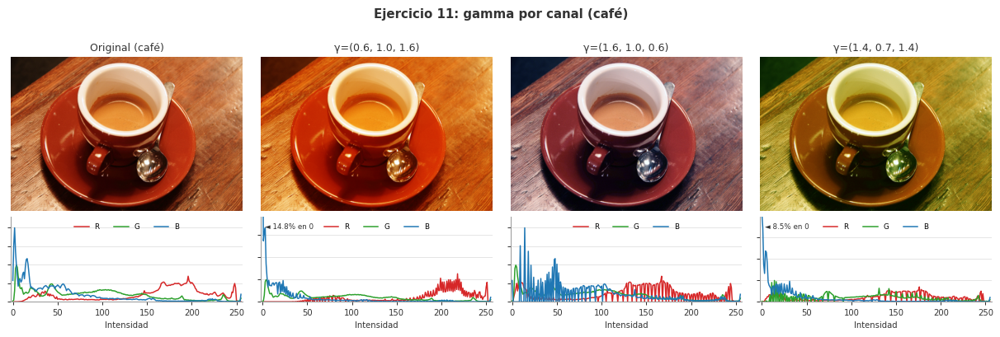

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original astronauta                  R   141.6    82.0    0  255  10.81    0.15      256
Original astronauta                  G   105.8    76.6    0  255  11.21    0.11      256
Original astronauta                  B    96.5    77.9    0  255  11.10    0.10      256
γ=(0.6, 1.0, 1.6)                    R   164.7    81.5    0  255  10.81    0.15      209
γ=(0.6, 1.0, 1.6)                    G   105.8    76.6    0  255  11.21    0.11      256
γ=(0.6, 1.0, 1.6)                    B    71.3    71.3    0  255  18.47    0.10      212
γ=(1.6, 1.0, 0.6)                    R   117.2    79.6    0  255  13.49    0.15      212
γ=(1.6, 1.0, 0.6)                    G   105.8    76.6    0  255  11.21    0.11      256
γ=(1.6, 1.0, 0.6)                    B   125.0    80.1    0  255  11.10    0.10      209
γ=(1.4, 0.7, 1.4)    

In [25]:
config11 = {
    "γ=(0.6, 1.0, 1.6)": (0.6, 1.0, 1.6),
    "γ=(1.6, 1.0, 0.6)": (1.6, 1.0, 0.6),
    "γ=(1.4, 0.7, 1.4)": (1.4, 0.7, 1.4),
}
for img_nombre, img in [("astronauta", astro), ("café", cafe)]:
    comparar([(f"Original ({img_nombre})", img)] + [(k, gamma_canales(img, v)) for k, v in config11.items()],
             titulo=f"Ejercicio 11: gamma por canal ({img_nombre})", ancho=3.4)
tabla([("Original astronauta", astro)] + [(k, gamma_canales(astro, v)) for k, v in config11.items()])

In [26]:
# Blanco, negro y grises: ¿siguen siendo neutros?
for v in (0, 64, 128, 192, 255):
    p = np.full((1, 1, 3), v, np.uint8)
    print(f"gris {v:>3} -> {gamma_canales(p, (0.6, 1.0, 1.6))[0, 0].tolist()}")

gris   0 -> [0, 0, 0]
gris  64 -> [111, 64, 28]
gris 128 -> [169, 128, 85]
gris 192 -> [215, 192, 162]
gris 255 -> [255, 255, 255]


### Interpretación y respuestas

Con una gamma diferente por canal, cada canal se aclara o se oscurece en distinta medida, por lo que la imagen adquiere una tonalidad hacia el canal con menor gamma. Con $\gamma=(0.6,1.0,1.6)$, el rojo aumenta y el azul disminuye, generando un tono cálido anaranjado; con $\gamma=(1.6,1.0,0.6)$ ocurre lo contrario y la imagen adquiere un tono frío azulado; y con $\gamma=(1.4,0.7,1.4)$ predomina el verde. Sí se generan dominancias de color, pero estas dependen de la intensidad: el negro y el blanco puros permanecen neutros porque $0^\gamma=0$ y $1^\gamma=1$, mientras que los tonos intermedios pueden adquirir una dominante más marcada. Por ejemplo, con $\gamma=(0.6,1.0,1.6)$, un gris 64 se transforma en $[111,64,28]$ y un gris 128 en $[169,128,85]$, produciendo un tinte naranja más evidente en sombras y tonos medios. La dominancia es mayor en las sombras porque allí la gamma tiene un efecto relativo más fuerte. Además, no se genera saturación adicional en 255, ya que los valores extremos permanecen dentro del rango. Este comportamiento corresponde al principio de las curvas de color y de los ajustes no lineales de color utilizados en programas de edición.


## Ejercicio 12: Intercambio de canales

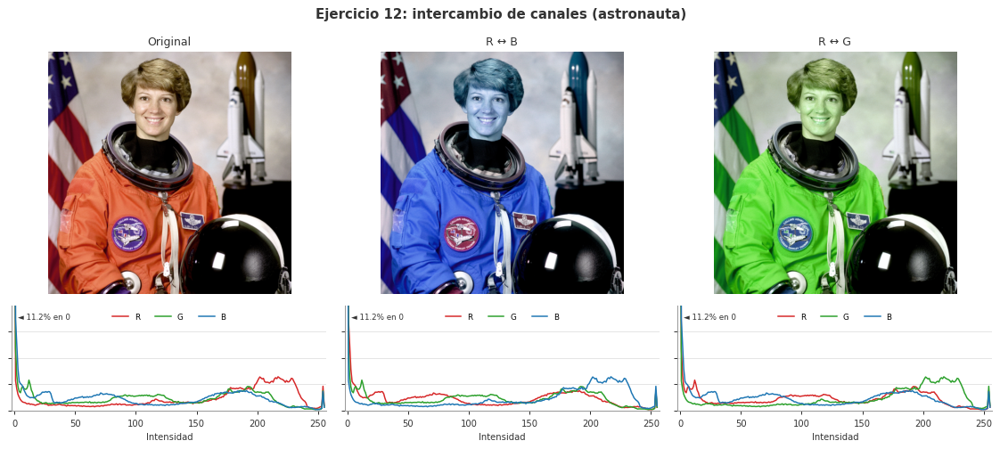

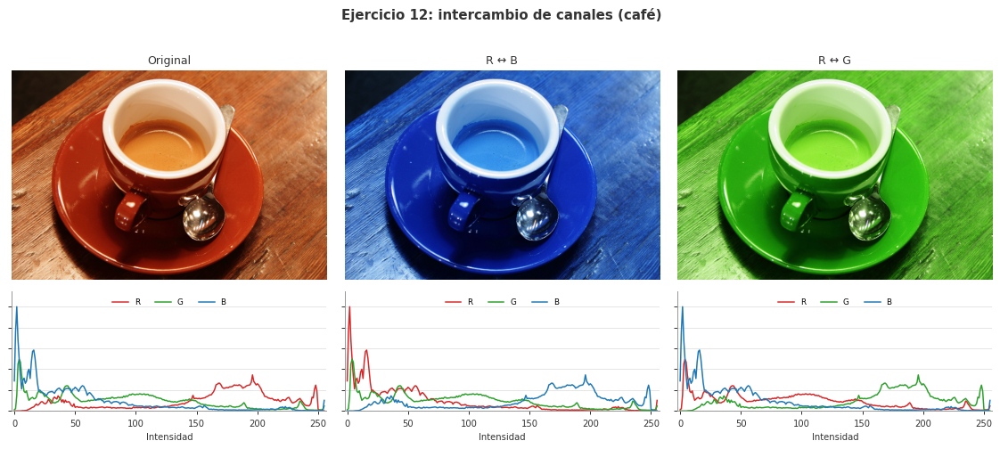

¿Imagen BGR de OpenCV == R↔B de la RGB? True
¿La luminancia cambia al intercambiar R↔B? media gris original = 115.4, con R↔B = 107.1


In [27]:
for img_nombre, img in [("astronauta", astro), ("café", cafe)]:
    comparar([("Original", img), ("R ↔ B", intercambiar_canales(img, "R", "B")),
              ("R ↔ G", intercambiar_canales(img, "R", "G"))],
             titulo=f"Ejercicio 12: intercambio de canales ({img_nombre})", ancho=4.2)

# El error clásico de OpenCV: mostrar en Matplotlib una imagen BGR sin convertir es exactamente un R ↔ B
import cv2
bgr_sin_convertir = cv2.imread("imagenes/color2.png")
print("¿Imagen BGR de OpenCV == R↔B de la RGB?", np.array_equal(bgr_sin_convertir, intercambiar_canales(astro, "R", "B")))
print("¿La luminancia cambia al intercambiar R↔B?",
      f"media gris original = {a_gris(astro).mean():.1f}, con R↔B = {a_gris(intercambiar_canales(astro, 'R', 'B')).mean():.1f}")

### Interpretación y respuestas

Al intercambiar los canales R y B, el traje naranja del astronauta se vuelve azul, la piel adquiere tonos azul-violeta y las franjas rojas de la bandera pasan a ser azules; en el café, la madera, el plato y el líquido también adquieren tonos azulados. Al intercambiar R y G, el naranja pasa a verde lima, la piel se vuelve verdosa y las franjas rojas de la bandera se vuelven verdes. Aunque los colores cambian, la forma, las sombras y los bordes permanecen intactos, por lo que la escena sigue siendo reconocible. Esto muestra que los canales RGB son matrices de valores y que el color depende de cómo se asignan esos valores a los componentes rojo, verde y azul de la pantalla. La información de forma está presente en los tres canales, mientras que el color depende de las diferencias entre ellos. Además, los canales no contribuyen de igual manera al brillo percibido, por lo que al intercambiar R y B la media de gris cambia de 115.4 a 107.1 aunque los valores de los píxeles sean los mismos, solo reordenados. Este intercambio también explica el error común en OpenCV, ya que `cv2.imread` carga las imágenes en formato BGR y, si se muestran directamente con Matplotlib, los canales R y B quedan intercambiados; por eso se utiliza `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)`.


## Ejercicio 13: Conversión a escala de grises vs manipulación RGB

OpenCV convierte a gris con la luminancia $Y = 0.299R + 0.587G + 0.114B$. Se compara con manipulaciones en RGB y se construye un ejemplo de **colores distintos con el mismo gris** (metámeros de luminancia).

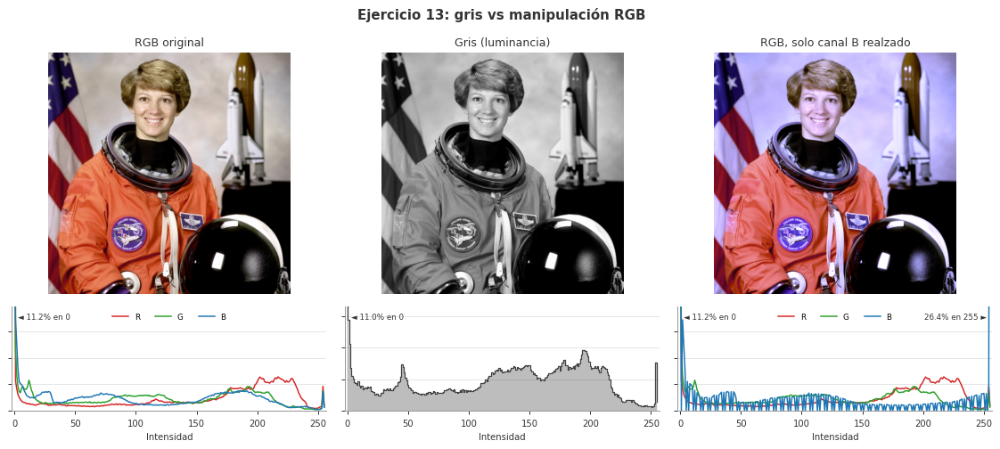

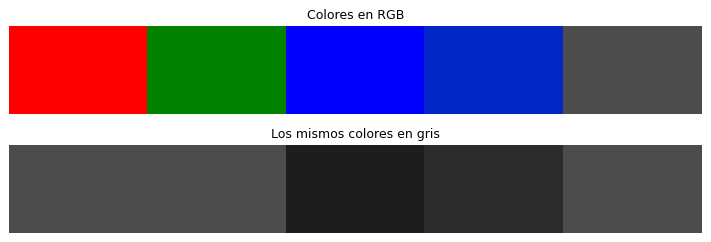

RGB [255, 0, 0]      -> gris 76
RGB [0, 130, 0]      -> gris 76
RGB [0, 0, 255]      -> gris 29
RGB [0, 38, 197]     -> gris 45
RGB [76, 76, 76]     -> gris 76


In [28]:
gris_astro = a_gris(astro)
comparar([("RGB original", astro), ("Gris (luminancia)", gris_astro),
          ("RGB, solo canal B realzado", lineal_canales(astro, (1, 1, 1.5), (0, 0, 0)))],
         titulo="Ejercicio 13: gris vs manipulación RGB", ancho=4.2)

# Colores muy distintos que producen el mismo gris
colores = np.array([[[255, 0, 0], [0, 130, 0], [0, 0, 255], [0, 38, 197], [76, 76, 76]]], dtype=np.uint8)
y = a_gris(colores)
fig, ejes = plt.subplots(2, 1, figsize=(8, 2.8))
ejes[0].imshow(colores, aspect="auto"); ejes[0].set_title("Colores en RGB", fontsize=10)
ejes[1].imshow(y, cmap="gray", vmin=0, vmax=255, aspect="auto"); ejes[1].set_title("Los mismos colores en gris", fontsize=10)
for ax in ejes:
    ax.axis("off")
fig.tight_layout()
plt.show()
for c, v in zip(colores[0], y[0]):
    print(f"RGB {str(c.tolist()):<16} -> gris {v}")

In [29]:
# Cuántos colores distintos se colapsan en cada nivel de gris
planos = astro.reshape(-1, 3)
codigos = (planos[:, 0].astype(np.int64) << 16) | (planos[:, 1].astype(np.int64) << 8) | planos[:, 2]
n_colores = np.unique(codigos).size
n_grises = np.unique(gris_astro).size
print(f"Colores RGB distintos en la imagen: {n_colores:,}")
print(f"Niveles de gris distintos tras convertir: {n_grises}")
print(f"En promedio, {n_colores / n_grises:,.0f} colores distintos se fusionan en cada nivel de gris")

Colores RGB distintos en la imagen: 113,382
Niveles de gris distintos tras convertir: 256
En promedio, 443 colores distintos se fusionan en cada nivel de gris


### Interpretación y respuesta

La conversión a escala de grises combina los tres canales RGB en un solo valor por píxel mediante la luminancia $Y=0.299R+0.587G+0.114B$, donde el verde aporta más a la percepción de claridad y el azul menos. Al hacer esta conversión se pierde la información de color, es decir, el tono y la saturación, porque muchos colores diferentes pueden producir el mismo nivel de gris; por ejemplo, el rojo puro [255, 0, 0], el verde [0, 130, 0] y el gris [76, 76, 76] producen el mismo valor 76. También pueden desaparecer bordes entre regiones que tienen colores diferentes pero una luminancia similar, y se pierde parte del detalle asociado al azul debido a que solo aporta el 11.4 % de la luminancia. En la imagen del astronauta se pasa de 113 382 colores distintos a solo 256 niveles de gris, por lo que muchos colores quedan representados por el mismo valor. En cambio, trabajar directamente con RGB conserva los tres canales y permite modificar un color específico sin afectar los demás. Por esto, la escala de grises es útil cuando interesa principalmente la estructura, los bordes y las texturas, pero implica descartar toda la información cromática.


## Ejercicio 14: Análisis de histogramas por canal

Primero se grafican los histogramas R, G y B de la original por separado; luego se aplica una transformación **distinta** a cada canal:

- R: lineal con desplazamiento, $R' = R + 40$
- G: lineal que comprime el contraste, $G' = 0.6G + 30$
- B: gamma $\gamma_B = 0.5$ (aclara las sombras del azul)

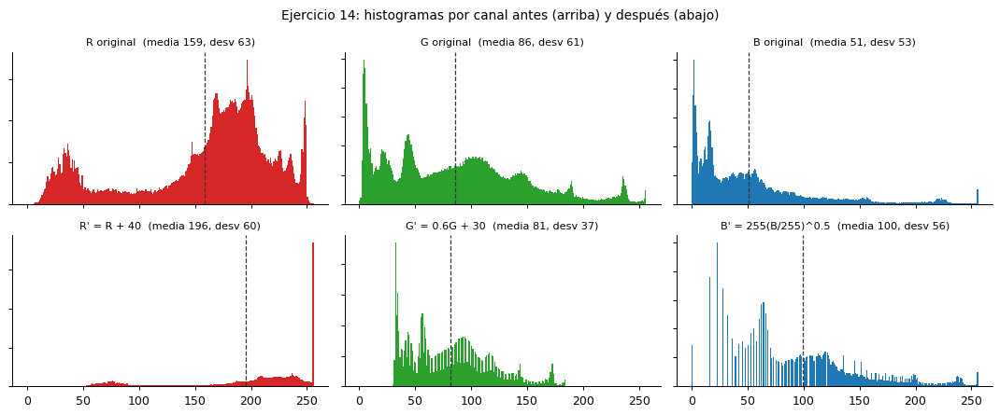

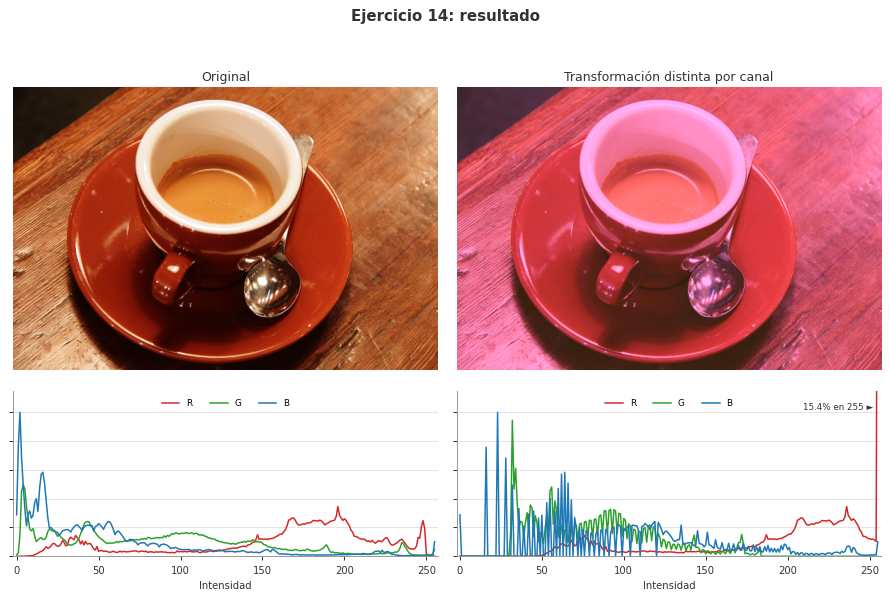

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             R   158.6    63.0    0  255   0.00    0.01      253
Original                             G    85.8    61.0    0  255   0.05    0.20      256
Original                             B    51.5    52.9    0  255   1.20    0.42      256
Transformada                         R   195.8    59.8   40  255   0.00   15.42      213
Transformada                         G    81.5    36.6   30  183   0.00    0.00      154
Transformada                         B    99.9    56.1    0  255   1.20    0.42      192


In [30]:
fig, ejes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
r14 = np.clip(cafe[..., 0].astype(float) + 40, 0, 255).astype(np.uint8)
g14 = a_uint8(0.6 * cafe[..., 1].astype(float) + 30)
b14 = gamma(cafe[..., 2], 0.5)
trans14 = np.dstack([r14, g14, b14])
colores_canal = {"R": "#d62728", "G": "#2ca02c", "B": "#1f77b4"}
etiquetas = {"R": "R' = R + 40", "G": "G' = 0.6G + 30", "B": "B' = 255(B/255)^0.5"}
for k, c in enumerate("RGB"):
    for fila, (img, t) in enumerate([(cafe, "original"), (trans14, etiquetas[c])]):
        ax = ejes[fila, k]
        ax.hist(img[..., k].ravel(), bins=256, range=(0, 256), color=colores_canal[c])
        m = img[..., k].mean()
        ax.axvline(m, color="#333333", linestyle="--", linewidth=1)
        ax.set_title(f"{c if fila == 0 else ''}{' original' if fila == 0 else t}  (media {m:.0f}, desv {img[..., k].std():.0f})", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_yticklabels([])
fig.suptitle("Ejercicio 14: histogramas por canal antes (arriba) y después (abajo)", fontsize=11)
fig.tight_layout()
plt.show()

comparar([("Original", cafe), ("Transformación distinta por canal", trans14)],
         titulo="Ejercicio 14: resultado", ancho=5)
tabla([("Original", cafe), ("Transformada", trans14)])

### Interpretación y respuestas

Cada transformación modifica el histograma de una manera diferente: con $R'=R+40$, el histograma se desplaza 40 niveles a la derecha sin cambiar mucho su forma, aunque los valores que superan 255 se acumulan en ese límite; con $G'=0.6G+30$, el histograma se comprime hacia el centro y se reduce su desviación estándar, haciendo que varios niveles se fusionen; y con $\gamma_B=0.5$, el histograma del azul se deforma de manera no uniforme, aumentando principalmente los valores bajos mientras que 0 y 255 permanecen fijos. El color percibido depende de la posición relativa de los tres histogramas, es decir, de la proporción entre R, G y B en cada píxel. En este caso, R queda más desplazado hacia valores altos que G y B, generando una mayor presencia de tonos rojos y naranjas; G pierde contraste al comprimirse, haciendo que la imagen se vea más plana en claridad; y B se aclara principalmente en las sombras, produciendo tonos azul-violeta en las zonas oscuras y matices fríos en los blancos. Cuando los tres canales tienen valores similares, los píxeles tienden a verse grises o neutros, mientras que cuando sus valores se separan aparecen dominancias de color. Por lo tanto, la posición y distribución de los histogramas permiten anticipar los cambios de color de la imagen.

## Ejercicio 15: Diseño de estilo visual

Se diseñan tres estilos combinando transformaciones lineales y gamma por canal:

| Estilo | R | G | B |
|---|---|---|---|
| Cálido | $1.10R + 15$ | $1.00G + 5$ | $0.85B - 10$ |
| Frío | $0.85R - 10$ | $1.00G + 5$ | $1.12B + 20$ |
| Alto contraste | por tramos (S) | por tramos (S) | por tramos (S) |

Para el alto contraste se usa la **misma** curva en S en los tres canales, puntos $(0,0),(60,20),(128,128),(196,235),(255,255)$, para no alterar el color.

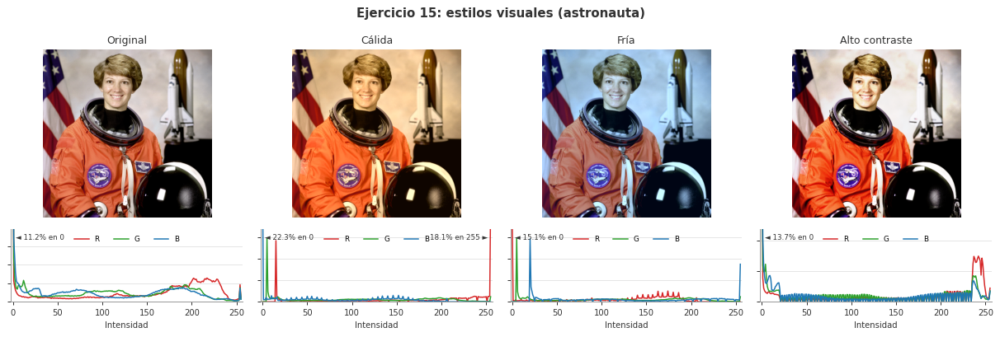

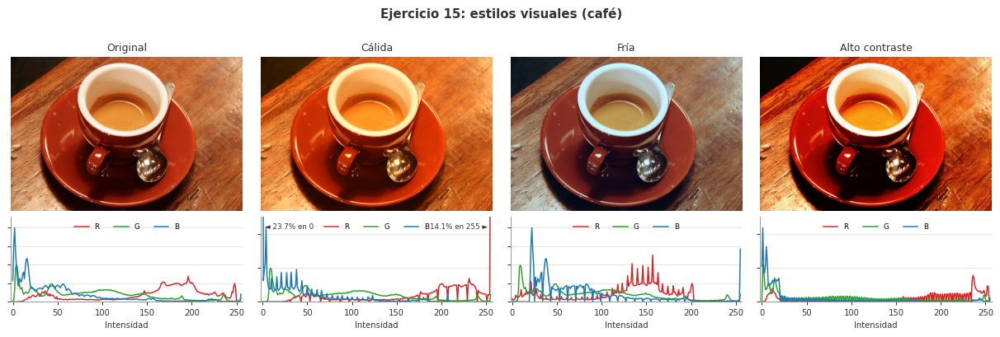

imagen                           canal   media    desv  min  max   %en0  %en255  niveles
----------------------------------------------------------------------------------------
Original                             R   141.6    82.0    0  255  10.81    0.15      256
Original                             G   105.8    76.6    0  255  11.21    0.11      256
Original                             B    96.5    77.9    0  255  11.10    0.10      256
Cálida                               R   168.5    87.8   15  255   0.00   18.14      219
Cálida                               G   110.7    76.6    5  255   0.00    0.89      251
Cálida                               B    73.8    64.0    0  207  22.31    0.00      208
Fría                                 R   111.7    67.5    0  207  15.13    0.00      208
Fría                                 G   110.7    76.6    5  255   0.00    0.89      251
Fría                                 B   126.7    84.9   20  255   0.00    6.64      211
Alto contraste       

In [31]:
def calido(img):
    return lineal_canales(img, (1.10, 1.00, 0.85), (15, 5, -10))

def frio(img):
    return lineal_canales(img, (0.85, 1.00, 1.12), (-10, 5, 20))

curva_s = [(0, 0), (60, 20), (128, 128), (196, 235), (255, 255)]
def alto_contraste(img):
    return por_tramos(img, curva_s)

for img_nombre, img in [("astronauta", astro), ("café", cafe)]:
    comparar([("Original", img), ("Cálida", calido(img)), ("Fría", frio(img)), ("Alto contraste", alto_contraste(img))],
             titulo=f"Ejercicio 15: estilos visuales ({img_nombre})", ancho=3.4)

tabla([("Original", astro), ("Cálida", calido(astro)), ("Fría", frio(astro)), ("Alto contraste", alto_contraste(astro))])

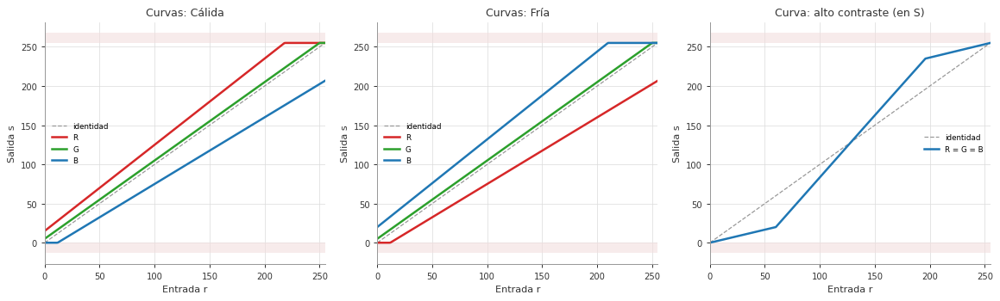

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
r = np.arange(256)
for ax, (t, a, b) in zip(ejes[:2], [("Cálida", (1.10, 1.00, 0.85), (15, 5, -10)), ("Fría", (0.85, 1.00, 1.12), (-10, 5, 20))]):
    curvas({c: np.clip(a[k] * r + b[k], 0, 255) for k, c in enumerate("RGB")}, titulo=f"Curvas: {t}", ax=ax)
    for linea, col in zip(ax.get_lines()[1:], ["#d62728", "#2ca02c", "#1f77b4"]):
        linea.set_color(col)
    ax.legend(fontsize=7, frameon=False)
rs, ss = zip(*curva_s)
curvas({"R = G = B": np.interp(r, rs, ss)}, titulo="Curva: alto contraste (en S)", ax=ejes[2])
fig.tight_layout()
plt.show()

### Justificación de los parámetros

En la imagen cálida, $R'=1.10R+15$ aumenta el rojo y $B'=0.85B-10$ reduce el azul, mientras $G'=G+5$ se mantiene casi igual para conservar una tonalidad dorada. Los desplazamientos también afectan las sombras y los cambios moderados buscan evitar una saturación excesiva, aunque un 18 % de los píxeles del canal R llega a 255. En la imagen fría, $R'=0.85R-10$ reduce el rojo y $B'=1.12B+20$ aumenta el azul, mientras $G'=G+5$ favorece una tonalidad cian. Mantener $a_G=1$ permite que el brillo percibido cambie poco, ya que el verde tiene una mayor influencia en la luminancia. Para el alto contraste se utiliza la misma curva en S para los tres canales, con puntos $(0,0),(60,20),(128,128),(196,235),(255,255)$. El tramo central tiene una pendiente aproximada de $1.58$, por lo que aumenta la separación entre los tonos medios, mientras que los extremos tienen pendientes cercanas a $0.33$ y $0.34$, comprimiendo sombras y luces. El punto $(128,128)$ mantiene aproximadamente el brillo medio y, al aplicar la misma curva a R, G y B, no se modifica la tonalidad de la imagen, sino principalmente el contraste. Como resultado, el histograma se extiende hacia los extremos y disminuye en la zona central.

# Conclusiones

1. Una transformación **lineal** $aI+b$ tiene una pendiente constante. El valor de $a$ controla el contraste porque aumenta o disminuye las diferencias entre los píxeles, mientras que $b$ modifica el brillo desplazando los valores de intensidad. Su principal problema es que, al cambiar demasiado estos valores, algunos píxeles pueden salir del rango $[0,255]$ y terminar saturándose.

2. Cuando los valores salen del rango $[0,255]$, se puede usar **clipping** o **normalización**. El clipping limita los valores a 0 y 255, pero puede hacer que varios valores diferentes terminen siendo iguales y se pierda información. La normalización conserva los valores dentro del rango, pero depende del mínimo y máximo de la imagen, por lo que unos pocos píxeles extremos pueden afectar bastante el resultado.

3. Las transformaciones **no lineales**, como las transformaciones por tramos y la gamma, tienen una pendiente que cambia según la intensidad. Esto permite aumentar el contraste en algunas zonas y reducirlo en otras sin afectar toda la imagen de la misma manera. Por ejemplo, una gamma con $\gamma<1$ permite aclarar las sombras manteniendo mejor los detalles de las zonas claras que una transformación lineal.

4. En una imagen RGB, si se aplica la misma transformación a los tres canales, principalmente se modifica el brillo y el contraste. En cambio, si se aplican transformaciones diferentes, también cambia el color de la imagen. Esto ocurre porque el color que percibimos depende de la relación entre los valores de R, G y B.

5. Los canales RGB pueden entenderse como tres matrices de números que contienen la información de la imagen. Al intercambiarlos o eliminar uno de ellos, la estructura y la posición de los objetos se mantienen, pero los colores cambian. En cambio, al convertir la imagen a escala de grises se pierde de forma permanente la información relacionada con el color.

6. Ninguna transformación puntual puede crear información que no estaba en la imagen originalmente; solamente modifica la distribución de los niveles existentes. Cuando la pendiente es menor que 1, algunos niveles pueden juntarse y perderse diferencias entre intensidades, mientras que cuando es mayor que 1 pueden aparecer espacios entre los niveles del histograma.


# Nivel de uso de la IA: Medio
1. Imagenes: la ia se uso para conseguir imagenes de uso libre para el desarrollo de la actividad 
2. Investigación: para busqueda de información y uso de las funciones de las librerias
3. Escritura: para mejorar la redaccion y agregar comentarios que la IA considere necesarios 
4. Verificación del codigo 
5. Corregir errores durante el desarrollo del taller